# Model Development

## Objectives

- To develop a model that predicts car prices using the features identified during the exploratory data analysis of the automobile dataset.

## 1. Import Data

We will use the cleaned data from the file "Data_wrangling_AutomobileData.ipynb". The output dataset obtained after running this notebook is named "clean_data_automobile.csv".

You can find the "Automobile Dataset" from the following link: https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data

In [42]:
# Import required librarires
import pandas as pd
import numpy as np

# Required librarires for visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import copy
import math

In [43]:
# Read file
file_name = "clean_data_automobile.csv" 
df = pd.read_csv(file_name, header =0)

df.head()

,Unnamed: 0,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,horsepower-binned,fuel-diesel,fuel-gas
0,0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,2.68,9.0,111,5000,21,27,13495.0,Low,False,True
1,1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,2.68,9.0,111,5000,21,27,16500.0,Low,False,True
2,2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,...,3.47,9.0,154,5000,19,26,16500.0,Medium,False,True
3,3,2,164,audi,std,four,sedan,fwd,front,99.8,...,3.40,10.0,102,5500,24,30,13950.0,Low,False,True
4,4,2,164,audi,std,four,sedan,4wd,front,99.4,...,3.40,8.0,115,5500,18,22,17450.0,Low,False,True


In [44]:
df.drop(['Unnamed: 0'], axis=1, inplace=True)

## 1. Simple Linear Regression 

Lest's recap the features selected to predict the car price:
- drive-wheels (categorical variable),
- width, Curb-weight, Engine-size, Horsepower (numerical variables).
- We could also include additional numerical variables if we lower the threshold for the Pearson correlation retained to 0.5, such as: wheel-base, length, width, bore, city-mpg, highway-mpg

In this stage, we will focus exclusively on numerical variables. While categorical features could be transformed into numerical ones through one‑hot encoding, that is not our current objective. Instead, we will apply Simple Linear Regression to predict car prices using three approaches: (1) scikit‑learn’s implementation with Stochastic Gradient Descent, (2) the Ordinary Least Squares method, and (3) a custom Gradient Descent algorithm inspired by the Machine Learning Specialization by Andrew Ng. Finally, we will compare the results across these methods.

#### 1. Stochastic Gradient Descent

In [45]:
df[['engine-size', 'price']].head(10)

,engine-size,price
0,130,13495.0
1,130,16500.0
2,152,16500.0
3,109,13950.0
4,136,17450.0
5,136,15250.0
6,136,17710.0
7,136,18920.0
8,131,23875.0
9,108,16430.0


In [46]:
X_train= df[['engine-size']]
y_train = df['price']

In [47]:
from sklearn.linear_model import SGDRegressor # performs best with normalized inputs
from sklearn.preprocessing import StandardScaler #  perform z-score normalization

scaler = StandardScaler() 
X_norm = scaler.fit_transform(X_train)
print(f"Peak to Peak range by column in Raw        X:{np.ptp(X_train,axis=0)}")   
print(f"Peak to Peak range by column in Normalized X:{np.ptp(X_norm,axis=0)}")

Peak to Peak range by column in Raw        X:engine-size    265
dtype: int64
Peak to Peak range by column in Normalized X:[6.39426992]


In [48]:
sgdr = SGDRegressor(max_iter=1000)
sgdr.fit(X_norm, y_train)
print(sgdr)
print(f"number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")

SGDRegressor()
number of iterations completed: 37, number of weight updates: 7438.0


In [49]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f"model parameters:                   w: {w_norm}, b:{b_norm}")

model parameters:                   w: [6915.25473751], b:[13208.58137967]


In [50]:
# make a prediction using sgdr.predict()
y_pred = sgdr.predict(X_norm)
# make a prediction using w,b. 
y_pred_sgd = np.dot(X_norm, w_norm) + b_norm 
print(f"prediction using np.dot() and sgdr.predict match: {(y_pred == y_pred_sgd).all()}")

print(f"Prediction on training set:\n{y_pred[:4]}" )
print(f"Target values \n{y_train[:4]}")

prediction using np.dot() and sgdr.predict match: True
Prediction on training set:
[13729.91635348 13729.91635348 17400.84510219 10225.84800244]
Target values 
0    13495.0
1    16500.0
2    16500.0
3    13950.0
Name: price, dtype: float64


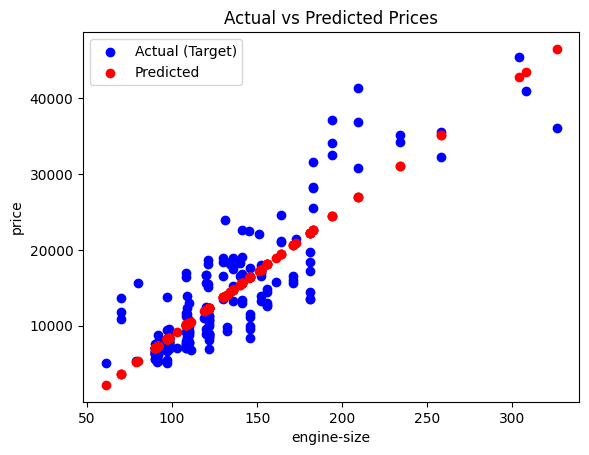

In [51]:
# plot predictions and targets vs original features 
plt.scatter(X_train, y_train, color='b', label='Actual (Target)')
plt.scatter(X_train, y_pred_sgd, color='r', label='Predicted')
    
plt.xlabel('engine-size')
plt.ylabel('price')
plt.title('Actual vs Predicted Prices')

plt.legend()
plt.show()

#### 2. Ordinary Least Squares method

In [52]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [53]:
print('coef w:', lr.coef_, 'intercept b:',lr.intercept_)

coef w: [166.86001569] intercept b: -7963.338906281024


In [54]:
# make a prediction using .predict()
y_pred = lr.predict(X_train)
# make a prediction using w,b. 
y_pred_lr = np.dot(X_train, lr.coef_) + lr.intercept_ 
print(f"prediction using np.dot() and lr.predict match: {(y_pred == y_pred_lr).all()}")

print(f"Prediction on training set:\n{y_pred[:4]}" )
print(f"Target values \n{y_train[:4]}")

prediction using np.dot() and lr.predict match: True
Prediction on training set:
[13728.4631336  13728.4631336  17399.38347881 10224.40280408]
Target values 
0    13495.0
1    16500.0
2    16500.0
3    13950.0
Name: price, dtype: float64


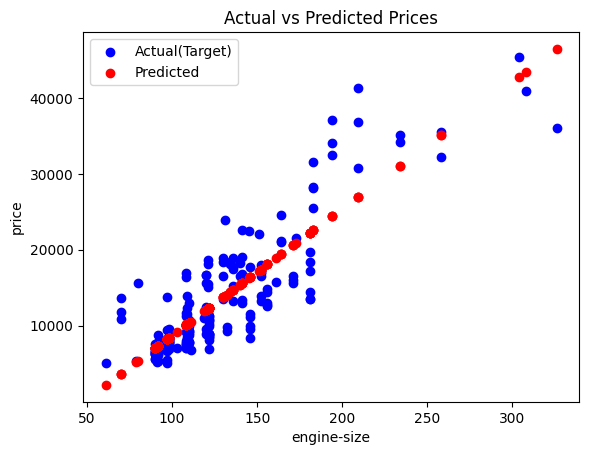

In [55]:
# plot predictions and targets vs original features 
plt.scatter(X_train, y_train, color='b', label='Actual(Target)')
plt.scatter(X_train, y_pred_lr, color='r', label='Predicted')
    
plt.xlabel('engine-size')
plt.ylabel('price')
plt.title('Actual vs Predicted Prices')

plt.legend()
plt.show()

#### 3. Gradient Descent

In [56]:
def compute_cost_matrix(X, y, w, b, verbose=False):
    """
    Computes the gradient for linear regression 
     Args:
      X : (array_like Shape (m,n)) variable such as house size 
      y : (array_like Shape (m,)) actual value 
      w : (array_like Shape (n,)) parameters of the model 
      b : (scalar               ) parameter of the model 
      verbose : (Boolean) If true, print out intermediate value f_wb
    Returns
      cost: (scalar)                      
    """ 
    m,n = X.shape
    
    # calculate f_wb for all examples.
    f_wb = X @ w + b  
    # calculate cost
    total_cost = (1/(2*m)) * np.sum((f_wb-y)**2)

    if verbose: print("f_wb:")
    if verbose: print(f_wb)
        
    return total_cost

In [57]:
def compute_gradient_matrix(X, y, w, b): 
    """
    Computes the gradient for linear regression 
 
    Args:
      X : (array_like Shape (m,n)) variable such as house size 
      y : (array_like Shape (m,1)) actual value 
      w : (array_like Shape (n,1)) Values of parameters of the model      
      b : (scalar )                Values of parameter of the model      
    Returns
      dj_dw: (array_like Shape (n,1)) The gradient of the cost w.r.t. the parameters w. 
      dj_db: (scalar)                The gradient of the cost w.r.t. the parameter b. 
                                  
    """
    m,n = X.shape
    #y = y.reshape(m,)
    
    f_wb = X @ w + b              
    error   = f_wb - y                   
    dj_dw  = (1/m) * (X.T @ error) # shap (n,)
    dj_db = (1/m) * np.sum(error) # scalar

    return dj_db,dj_dw


In [58]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    """
    Performs batch gradient descent to learn theta. Updates theta by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      X : (array_like Shape (m,n)    matrix of examples 
      y : (array_like Shape (m,))    target value of each example
      w_in : (array_like Shape (n,)) Initial values of parameters of the model
      b_in : (scalar)                Initial value of parameter of the model
      cost_function: function to compute cost
      gradient_function: function to compute the gradient
      alpha : (float) Learning rate
      num_iters : (int) number of iterations to run gradient descent
    Returns
      w : (array_like Shape (n,)) Updated values of parameters of the model after
          running gradient descent
      b : (scalar)                Updated value of parameter of the model after
          running gradient descent
    """
    
    # number of training examples
    m = len(X)
    m, n = X.shape
    print("X:", X.shape, "y:", y.shape, "w_in:", w_in.shape, "b_in:", type(b_in))
    # An array to store values at each iteration primarily for graphing later
    hist={}
    hist["cost"] = []; hist["params"] = []; hist["grads"]=[]; hist["iter"]=[];
   
    w = copy.deepcopy(w_in).reshape(n,)  #avoid modifying global w within function
    b = b_in
    save_interval = np.ceil(num_iters/10000) # prevent resource exhaustion for long runs

    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db,dj_dw = gradient_function(X, y, w, b)   
        #print(f"X:{X.shape}, y:{y.shape}, w:{w.shape}, dj_db:{type(dj_db)}, dj_dw:{dj_dw.shape}")
        
        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db               
      
        # Save cost J,w,b at each save interval for graphing
        if i == 0 or i % save_interval == 0:     
            hist["cost"].append(cost_function(X, y, w, b))
            hist["params"].append([w,b])
            hist["grads"].append([dj_dw,dj_db])
            hist["iter"].append(i)

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            #print(f"Iteration {i:4d}: Cost {cost_function(X, y, w, b):8.2f}   ")
            cst = cost_function(X, y, w, b)
            print(f"Iteration {i:9d}, Cost: {cst:0.5e}")
    return w, b, hist #return w,b and history for graphing
  

In [59]:
def run_gradient_descent_feng(X,y,iterations=1000, alpha = 1e-6):
    m,n = X.shape
    
    # initialize parameters
    initial_w = np.zeros(n)
    initial_b = 0
    # run gradient descent
    w_out, b_out, hist_out = gradient_descent(X ,y, initial_w, initial_b,
                                               compute_cost_matrix, compute_gradient_matrix, alpha, iterations)
    print(f"w,b found by gradient descent: w: {w_out}, b: {b_out:0.4f}")
    
    return(w_out, b_out, hist_out)

In [69]:
model_w, model_b, J_hist = run_gradient_descent_feng(X_train, y_train, 1000000, alpha = 1.1e-4)

X: (201, 1) y: (201,) w_in: (1,) b_in: <class 'int'>
Iteration         0, Cost: 1.10110e+08
Iteration    100000, Cost: 7.87721e+06
Iteration    200000, Cost: 7.55453e+06
Iteration    300000, Cost: 7.51584e+06
Iteration    400000, Cost: 7.51120e+06
Iteration    500000, Cost: 7.51064e+06
Iteration    600000, Cost: 7.51057e+06
Iteration    700000, Cost: 7.51056e+06
Iteration    800000, Cost: 7.51056e+06
Iteration    900000, Cost: 7.51056e+06
w,b found by gradient descent: w: engine-size    166.858609
dtype: float64, b: -7963.1414


In [70]:
def plot_cost_i(hist):
# plot cost versus iteration  
    cost_values = hist["cost"]
    fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
    ax1.plot(cost_values)
    ax2.plot(100 + np.arange(len(cost_values[100:])), cost_values[100:])
    ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
    ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
    ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
    plt.show()

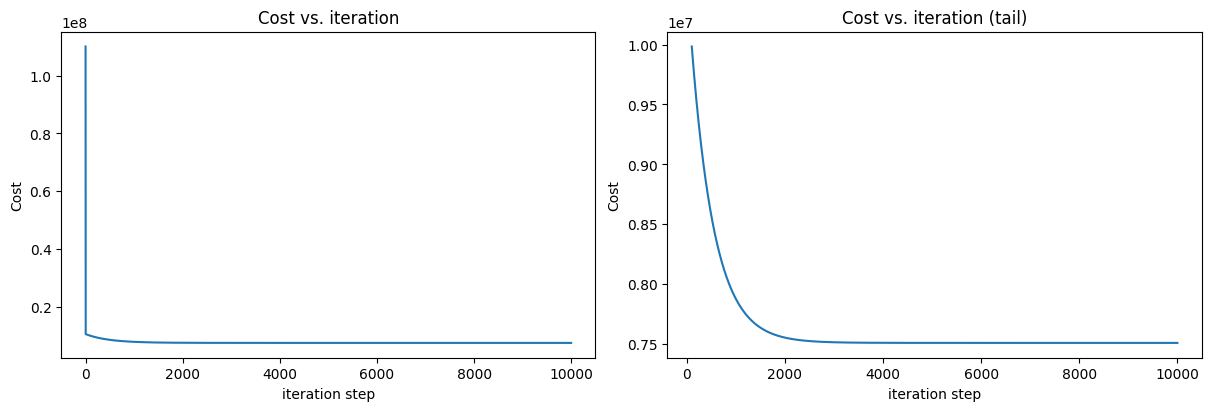

In [71]:
plot_cost_i(J_hist)

In [72]:
def plot_cost_i_w(X,y,hist):
    ws = np.array([ p[0] for p in hist["params"]])
    rng = max(abs(ws[:,0].min()),abs(ws[:,0].max()))
    wr = np.linspace(-rng+0.27,rng+0.27,20)
    #cst = [compute_cost(X,y,np.array([wr[i],-32, -67, -1.46]), 221) for i in range(len(wr))]
    cst = [compute_cost_matrix(X, y, np.array([wr[i]]), 221) 
    
       for i in range(len(wr))]

    fig,ax = plt.subplots(1,2,figsize=(12,3))
    ax[0].plot(hist["iter"], (hist["cost"]));  ax[0].set_title("Cost vs Iteration")
    ax[0].set_xlabel("iteration"); ax[0].set_ylabel("Cost")
    ax[1].plot(wr, cst); ax[1].set_title("Cost vs w[0]")
    ax[1].set_xlabel("w[0]"); ax[1].set_ylabel("Cost")
    ax[1].plot(ws[:,0],hist["cost"])
    plt.show()

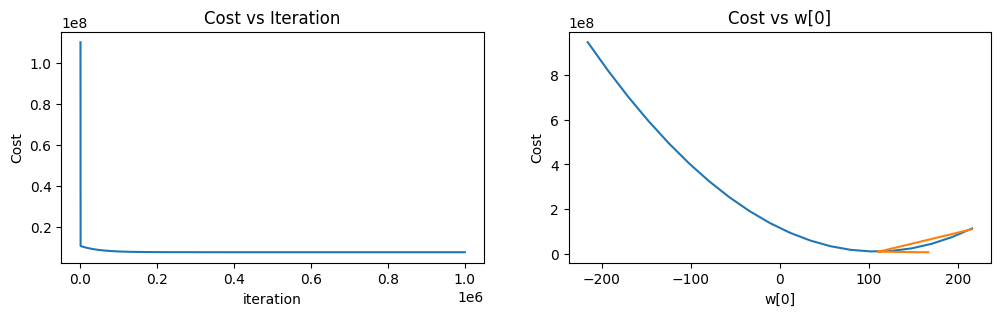

In [73]:
plot_cost_i_w(X_train, y_train, J_hist)

In [74]:
m = X_train.shape[0]
X_train_np = X_train.values
predicted = np.zeros(m)
w = model_w.values[0]
b = model_b

for i in range(m):
    predicted = w * X_train_np[:, 0] + b

print(f"Prediction on training set:\n{predicted[:4]}" )
print(f"Target values \n{y_train[:4]}")

Prediction on training set:
[13728.47777963 13728.47777963 17399.36717901 10224.44698931]
Target values 
0    13495.0
1    16500.0
2    16500.0
3    13950.0
Name: price, dtype: float64


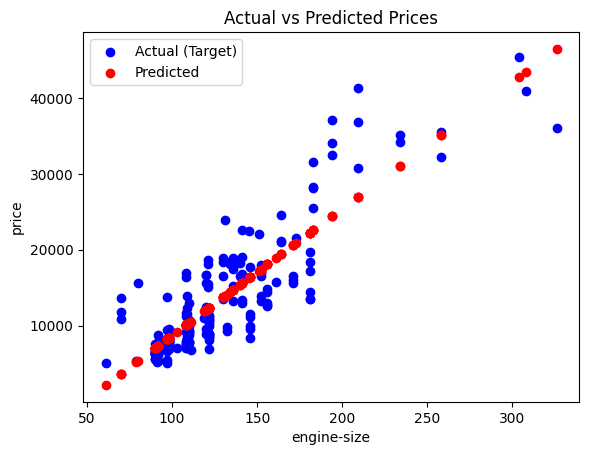

In [75]:
# plot predictions and targets vs original features 
plt.scatter(X_train, y_train, color='b', label='Actual (Target)')
plt.scatter(X_train, predicted, color='r', label='Predicted')
    
plt.xlabel('engine-size')
plt.ylabel('price')
plt.title('Actual vs Predicted Prices')

plt.legend()
plt.show()

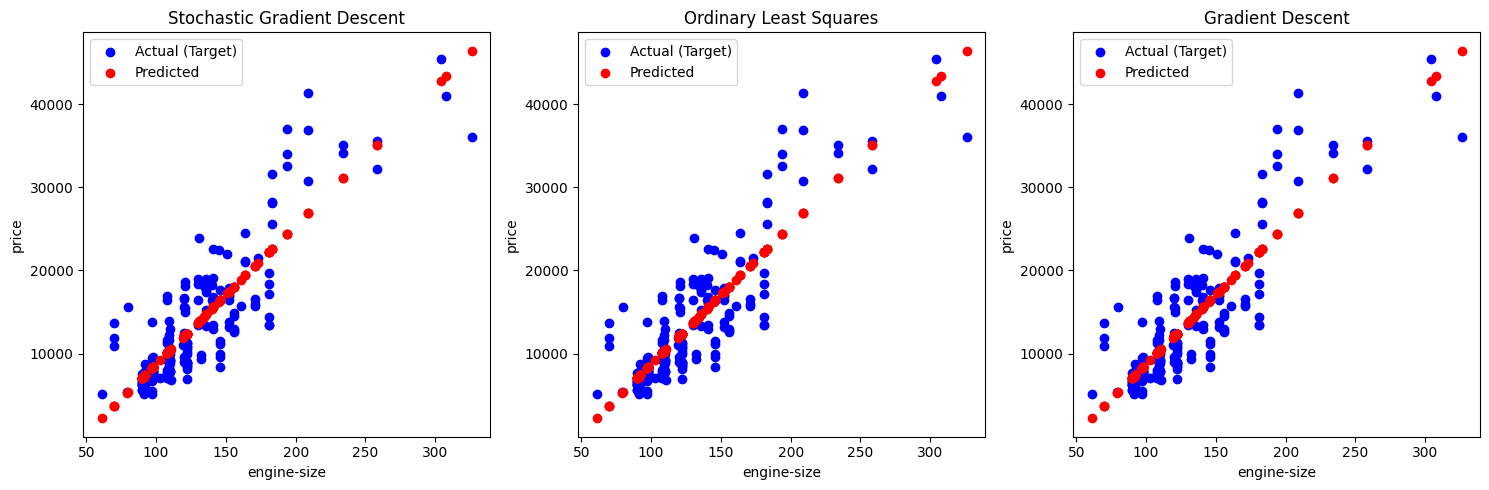

In [76]:
# plot the 03 methods
cols = [y_pred_sgd, y_pred_lr, predicted]
labels = ['Stochastic Gradient Descent', 'Ordinary Least Squares', 'Gradient Descent']

fig,axes = plt.subplots(1, 3, figsize=(15,5))

for i, (col, lab) in enumerate(zip(cols, labels)):   # i = index, col = column name
    axes[i].scatter(X_train, y_train, color='b', label='Actual (Target)')
    axes[i].scatter(X_train, col, color='r', label='Predicted')
    axes[i].set_xlabel('engine-size')
    axes[i].set_ylabel('price')
    axes[i].set_title(lab)
    axes[i].legend()

plt.tight_layout()
plt.show()


We have the same results for the three methods.

- If your dataset is small (e.g., a few hundred observations, few variables) → OLS is ideal: fast and exact.
- If your dataset is large (thousands/millions of rows, many variables) → Gradient Descent is preferable: scalable and flexible.
- If you want to train a model on streaming data or extremely large datasets (Big Data, deep learning) → SGD is essential: it allows incremental and fast updates.

## 2. Multiple Linear Regression 

Multiple Linear Regression is very similar to Simple Linear Regression, but this method is used to explain the relationship between one continuous response (dependent) variable our target and two or more predictor (independent) variables

From the previous section we know that other good predictors of price could be:

- Horsepower
- Curb-weight
- Engine-size
- Highway-mpg
Let's develop a model using these variables as the predictor variables.

#### 0. Feature Scaling

In [77]:
Z = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]

scaler = StandardScaler() 
Z_norm = scaler.fit_transform(Z)
print(f"Peak to Peak range by column in Raw        X:{np.ptp(Z,axis=0)}")   
print(f"Peak to Peak range by column in Normalized X:{np.ptp(Z_norm,axis=0)}")

Peak to Peak range by column in Raw        X:horsepower      214
curb-weight    2578
engine-size     265
highway-mpg      38
dtype: int64
Peak to Peak range by column in Normalized X:[5.74148959 4.99604353 6.39426992 5.58973491]


#### 1. Stochastic Gradient Descent

In [78]:
sgdz= SGDRegressor(max_iter=1000)
sgdz.fit(Z_norm, y_train)

print(sgdz)
print(f"number of iterations completed: {sgdz.n_iter_}, number of weight updates: {sgdz.t_}")

SGDRegressor()
number of iterations completed: 39, number of weight updates: 7840.0


In [79]:
b_normz = sgdz.intercept_
w_normz = sgdz.coef_
print(f"model parameters:                   w: {w_normz}, b:{b_normz}")

model parameters:                   w: [1936.71939476 2374.44908945 3394.47959128  136.1208947 ], b:[13205.0275794]


In [80]:
# make a prediction using sgdr.predict()
y_pred_sgdz = sgdz.predict(Z_norm)
# make a prediction using w,b. 
y_predz = np.dot(Z_norm, w_normz) + b_normz  
print(f"prediction using np.dot() and sgdr.predict match: {(y_predz == y_pred_sgdz).all()}")

print(f"Prediction on training set:\n{y_predz[:4]}" )
print(f"Target values \n{y_train[:4]}")

prediction using np.dot() and sgdr.predict match: True
Prediction on training set:
[13747.10453371 13747.10453371 19028.77924825 10648.55721131]
Target values 
0    13495.0
1    16500.0
2    16500.0
3    13950.0
Name: price, dtype: float64


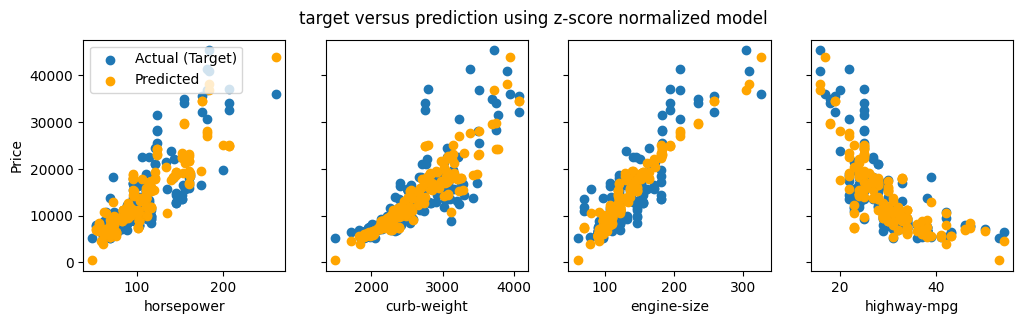

In [81]:
# plot predictions and targets vs original features    
fig,ax=plt.subplots(1,4,figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(Z.iloc[:,i],y_train, label = 'Actual (Target)')
    ax[i].set_xlabel(Z.columns[i])
    ax[i].scatter(Z.iloc[:,i],y_predz,color="orange", label = 'Predicted')
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()

#### 2. Ordinary Least Squares method

In [82]:
lm = LinearRegression()
lm.fit(Z_norm, y_train)


LinearRegression()

In [83]:
b_normols = lm.intercept_
w_normols = lm.coef_
print(f"model parameters:                   w: {w_normols}, b:{b_normols}")

model parameters:                   w: [2000.13761043 2430.08281612 3375.39558074  248.4744273 ], b:13207.129353233831


In [84]:
# make a prediction using .predict()
y_predm = lm.predict(Z_norm)
# make a prediction using w,b. 
y_pred_lm = np.dot(Z_norm, lm.coef_) + lm.intercept_ 
print(f"prediction using np.dot() and lr.predict match: {(y_predm == y_pred_lm).all()}")

print(f"Prediction on training set:\n{y_predm[:4]}" )
print(f"Target values \n{y_train[:4]}")

prediction using np.dot() and lr.predict match: True
Prediction on training set:
[13698.95609311 13698.95609311 19056.78572196 10621.59764327]
Target values 
0    13495.0
1    16500.0
2    16500.0
3    13950.0
Name: price, dtype: float64


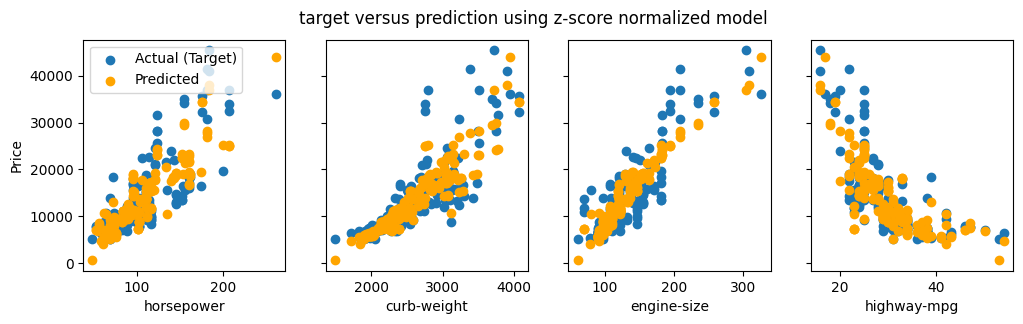

In [85]:
# plot predictions and targets vs original features    
fig,ax = plt.subplots(1,4,figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(Z.iloc[:,i],y_train, label = 'Actual (Target)')
    ax[i].set_xlabel(Z.columns[i])
    ax[i].scatter(Z.iloc[:,i],y_predm,color="orange", label = 'Predicted')
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()

#### 3. Gradient Descent

In [86]:
model_wm, model_bm, J_histm = run_gradient_descent_feng(Z_norm, y_train, 1000000, alpha = 1.4e-4)

X: (201, 4) y: (201,) w_in: (4,) b_in: <class 'int'>
Iteration         0, Cost: 1.18588e+08
Iteration    100000, Cost: 5.98821e+06
Iteration    200000, Cost: 5.98764e+06
Iteration    300000, Cost: 5.98759e+06
Iteration    400000, Cost: 5.98758e+06
Iteration    500000, Cost: 5.98758e+06
Iteration    600000, Cost: 5.98758e+06
Iteration    700000, Cost: 5.98758e+06
Iteration    800000, Cost: 5.98758e+06
Iteration    900000, Cost: 5.98758e+06
w,b found by gradient descent: w: [2000.13537102 2430.0802396  3375.39841721  248.47233857], b: 13207.1294


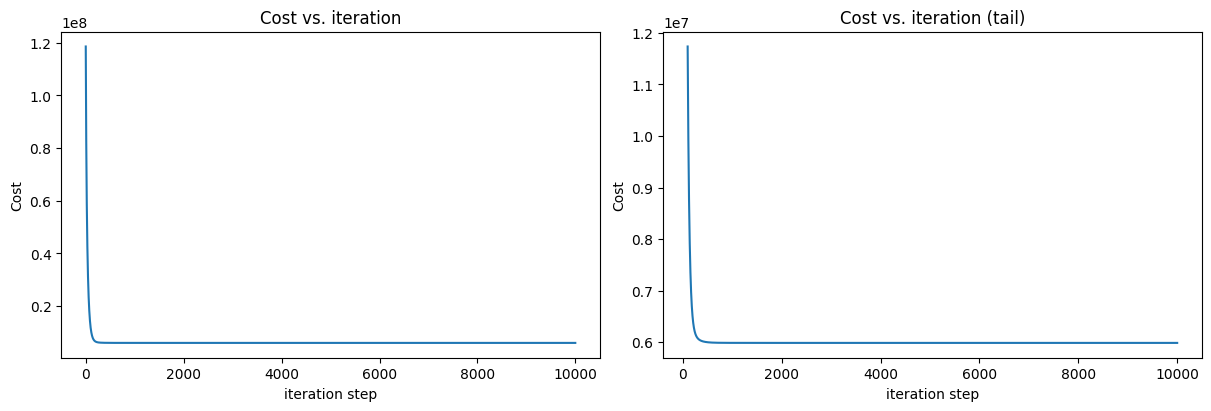

In [87]:
plot_cost_i(J_histm)

In [88]:
# Prediction
m = X_train.shape[0]
X_train_np = X_train.values
y_predm_gd = np.zeros(m)
w = model_wm
b = model_bm
y_predm_gd = Z_norm @ w + b

print(f"Prediction on training set:\n{y_predm_gd[:4]}" )
print(f"Target values \n{y_train[:4]}")

Prediction on training set:
[13698.95702087 13698.95702087 19056.78450605 10621.5978063 ]
Target values 
0    13495.0
1    16500.0
2    16500.0
3    13950.0
Name: price, dtype: float64


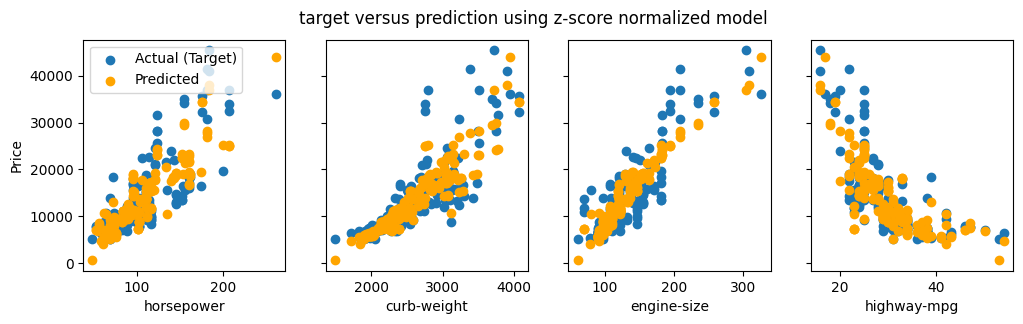

In [182]:
# plot predictions and targets vs original features    
fig,ax=plt.subplots(1,4,figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(Z.iloc[:,i],y_train, label = 'Actual (Target)')
    ax[i].set_xlabel(Z.columns[i])
    ax[i].scatter(Z.iloc[:,i], y_predm_gd, color="orange", label = 'Predicted')
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()

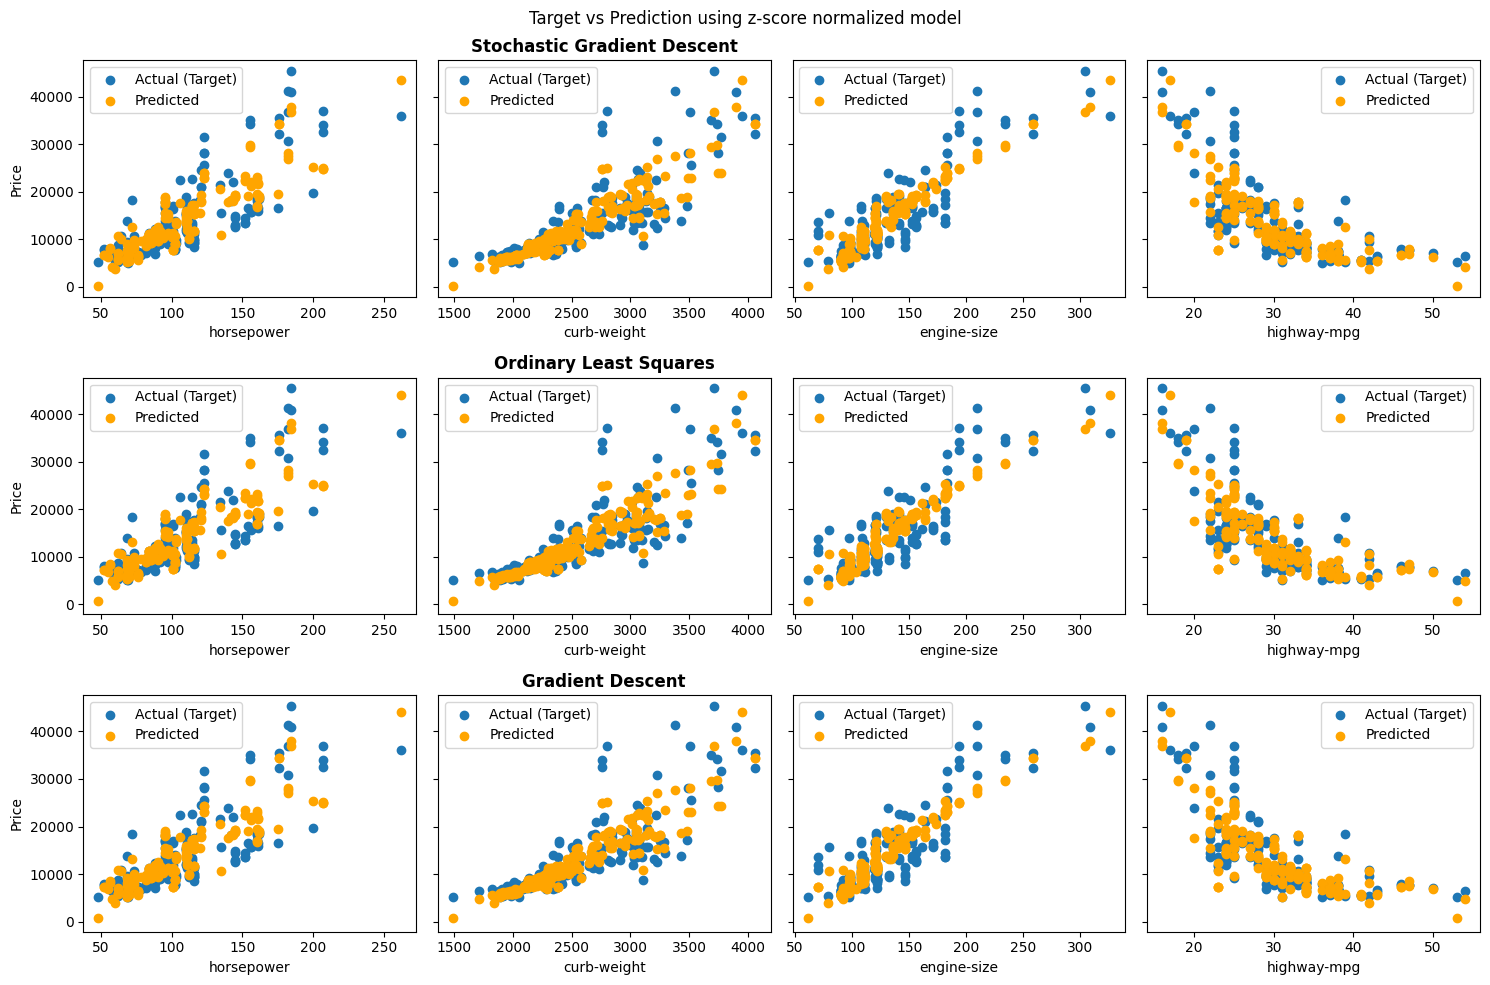

In [189]:
# Plot 03 methods

cols = [y_predz, y_predm, y_predm_gd]# Predictions
labels = ['Stochastic Gradient Descent', 'Ordinary Least Squares', 'Gradient Descent']# 03 methods

# plot 3 rows, 4 columns
fig, axes = plt.subplots(3, 4, figsize=(15, 10), sharey=True)

for row, (col, lab) in enumerate(zip(cols, labels)):
    for i in range(Z.shape[1]):   # 4 features
        ax = axes[row, i]
        ax.scatter(Z.iloc[:, i], y_train, label='Actual (Target)')
        ax.scatter(Z.iloc[:, i], col, color="orange", label='Predicted')
        ax.set_xlabel(Z.columns[i])
        if i == 0:   # mettre le label de l’axe y seulement sur la première colonne
            ax.set_ylabel("Price")

        ax.legend()

    axes[row, 1].set_title(lab, fontsize=12, fontweight="bold")

fig.suptitle("Target vs Prediction using z-score normalized model")
plt.tight_layout()
plt.show()



We obtain the same results for the three methods

## 2. Model Evaluation using Visualization

We need to evaluate our models and choose the best one.

#### a. Regression plot

A scatterplot with a fitted regression line, clearly showing the strength and direction of the relationship between the two variables.

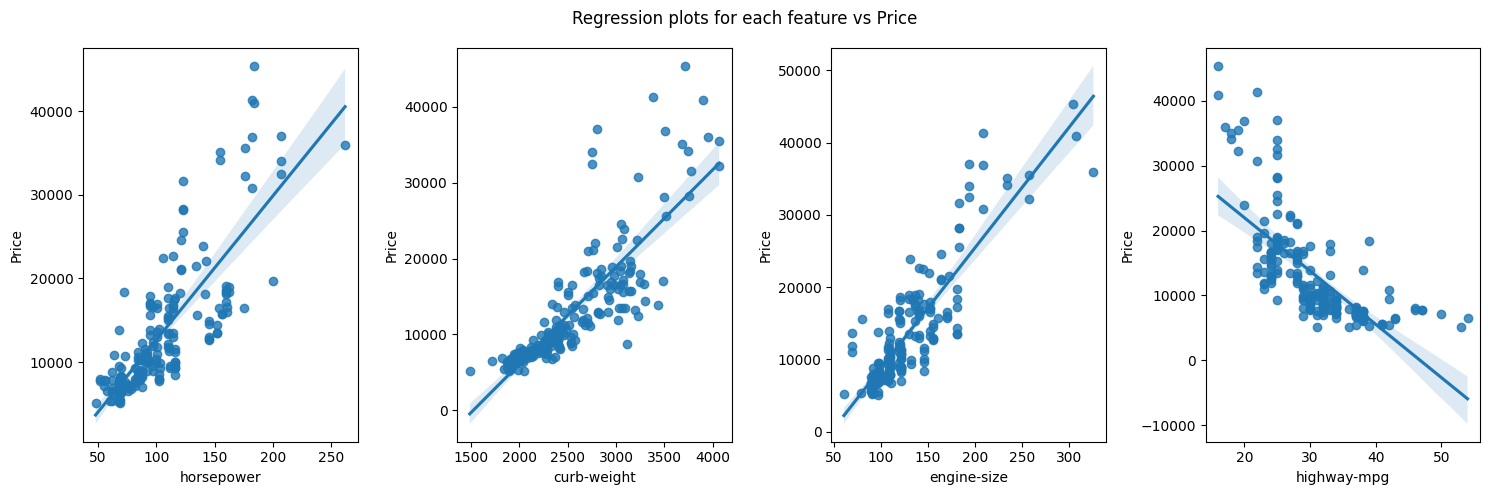

In [190]:
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for i in range(Z.shape[1]):   # 4 features
    ax = axes[i]              # sélectionner le bon sous-graphe
    sns.regplot(x=Z.iloc[:, i], y=df["price"], ax=ax)
    ax.set_xlabel(Z.columns[i])
    ax.set_ylabel("Price")

fig.suptitle("Regression plots for each feature vs Price")
plt.tight_layout()
plt.show()

- **Horsepower vs Price:**
The scatterplot shows a clear positive correlation: as horsepower increases, car prices tend to rise. This makes sense because more powerful engines are usually found in higher‑end vehicles.
- **Curb‑weight vs Price:**
Again, a positive correlation: heavier cars generally cost more. Heavier weight often reflects larger, more luxurious models with more materials and features.
- **Engine‑size vs Price:**
This is one of the strongest positive correlations in your plots. Larger engines are strongly associated with higher prices, which aligns with expectations in automotive markets.
- **Highway‑mpg vs Price:**
Here the relationship flips: a negative correlation. Cars with higher fuel efficiency (more miles per gallon) tend to be cheaper, while less efficient cars (lower mpg) are often larger, more powerful, and more expensive.


- The first three features (horsepower, curb‑weight, engine‑size) are direct drivers of price: bigger, stronger, heavier cars cost more.
- The last feature (highway‑mpg) is inversely related to price.

- Weak fit: The scatter shows a lot of spread around the line, so while there is a trend, it’s not a perfect predictor.
- Possible non‑linearity: For example, price might rise quickly with horsepower up to a point, then level off, or even follow a curved pattern. A straight line can’t capture that.
- Other influences: Car price depends on many factors (brand, design, luxury features, market demand), so a single feature’s linear relationship will always look noisy.


#### b. Residual plot

A **residual** is the difference between the observed value y and the predicted value yhat. In a regression plot, it’s the vertical distance from a data point to the fitted line.  
A **residual plot** graphs these residuals on the y‑axis against the independent variable on the x‑axis.  
What matters is the **pattern of the residuals**:
- If they are randomly scattered around zero, the variance is constant and a linear model is appropriate.
- If they show structure (curves, clusters, or increasing spread), this suggests the relationship may be non‑linear or the model is mis‑specified.

👉 In essence: residual plots help check whether a linear model is a good fit by revealing randomness versus systematic patterns in the errors.



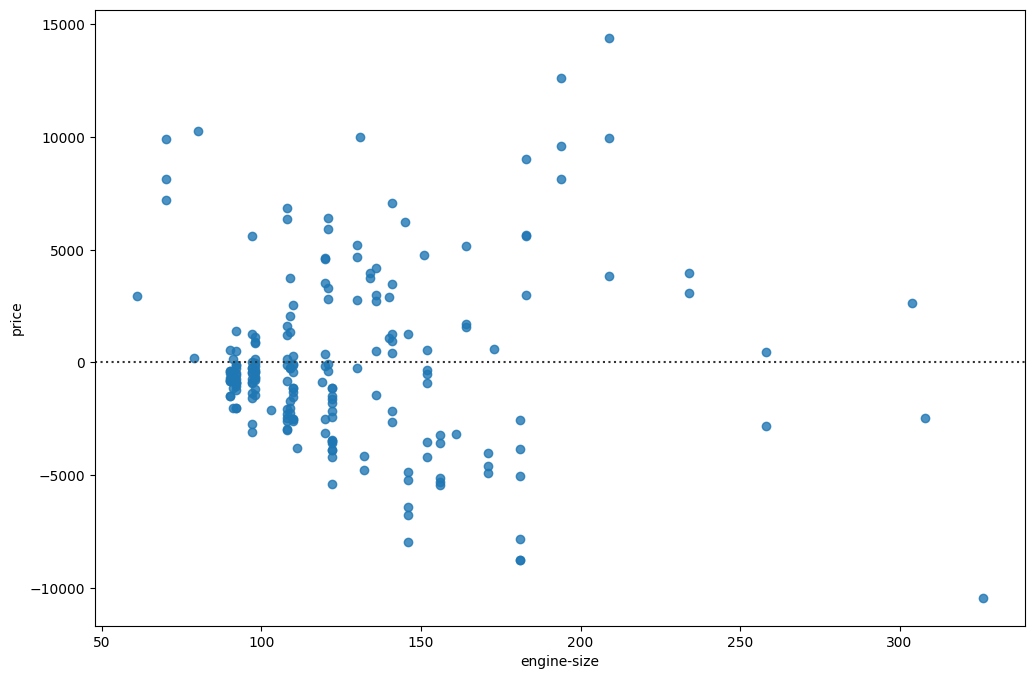

In [66]:
plt.figure(figsize=(12,8))
sns.residplot(x=df['engine-size'], y=df['price'])
plt.show()

The residual plot shows that the errors are not randomly scattered around the x‑axis, suggesting that a non‑linear model may better capture the relationship in this data.

#### c. Multiple Linear Regression

Visualizing a ***multiple linear regression*** model is trickier than with simple regression, since we can’t rely on a single regression or residual plot.
A practical approach is to compare the ***distribution of predicted values*** from the model with the ***distribution of actual values***. If the two distributions align closely, the model provides a good fit.

👉 In essence: for multiple regression, we check how well the predicted value distribution matches the real data distribution.



C:\Users\abouf\AppData\Local\Temp\ipykernel_21576\1507725612.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
C:\Users\abouf\AppData\Local\Temp\ipykernel_21576\1507725612.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  s

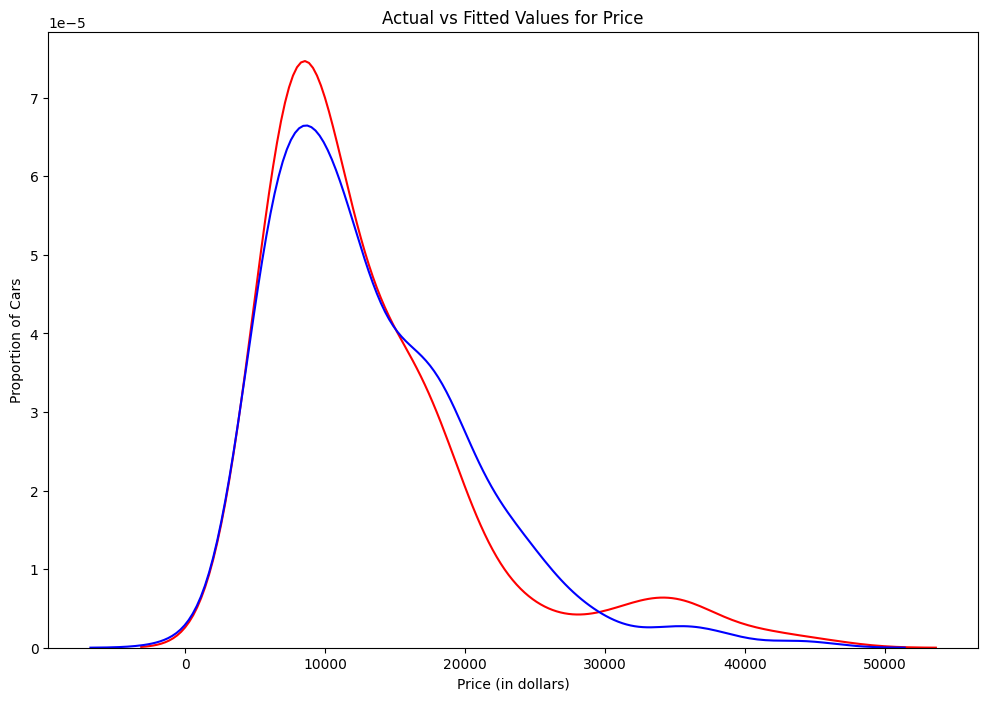

In [89]:
plt.figure(figsize=(12, 8))

ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
sns.distplot(y_predm, hist=False, color="b", label="Fitted Values" , ax=ax1)


plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')

plt.show()
plt.close()

The fitted values overlap with the actual values to some extent, indicating a reasonable fit, though the model still leaves room for improvement.


#### Kernel Density Estimation (KDE) Plots

With the deprecation of Seaborn distplot, KDE plots serve as a modern and effective method for assessing model performance.

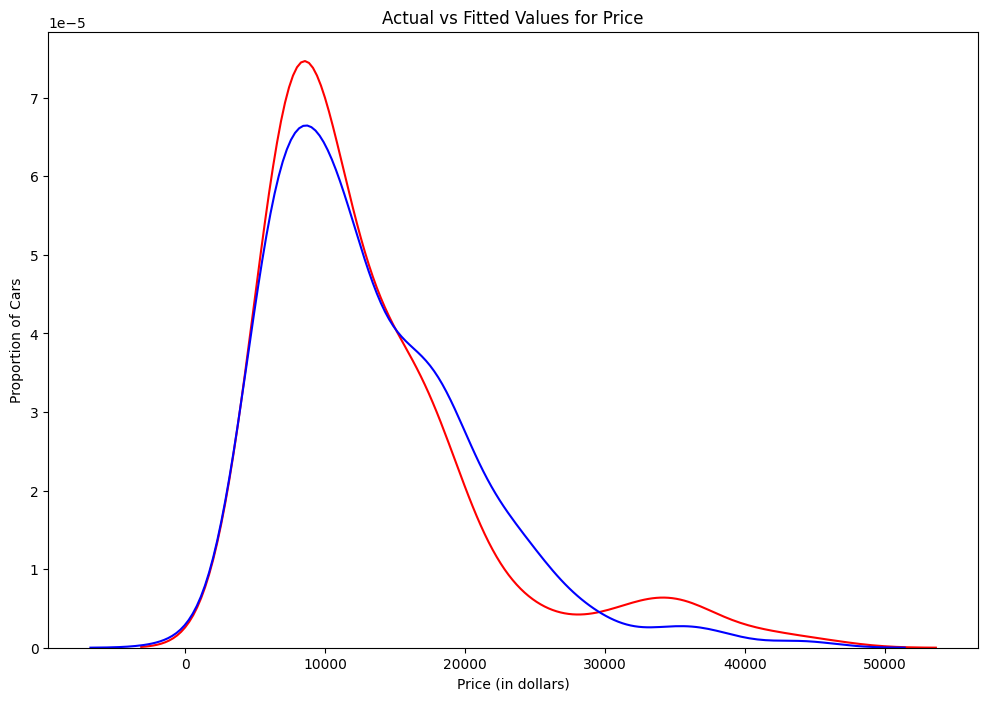

In [90]:
plt.figure(figsize=(12, 8))

ax1 = sns.kdeplot(df['price'], color="r", label="Actual Value")
sns.kdeplot(y_predm, color="b", label="Fitted Values" , ax=ax1)


plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')

plt.show()
plt.close()

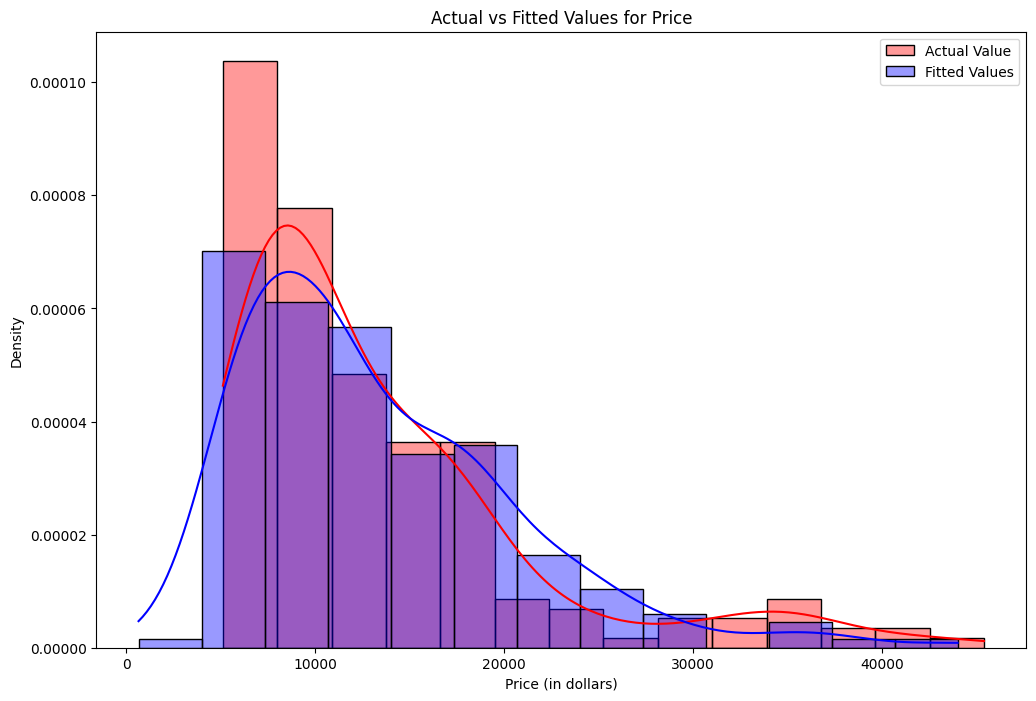

In [91]:
plt.figure(figsize=(12, 8))

# Actual Value Histogram
sns.histplot(df['price'], color="r", label="Actual Value", 
             stat="density", kde=True, alpha=0.4)

# Fitted Values Histogram
sns.histplot(y_predm, color="b", label="Fitted Values", 
             stat="density", kde=True, alpha=0.4)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Density')
plt.legend()
plt.show()
plt.close()

**sns.histplot** visualizes the distribution of data by showing the frequency or density of values, making it easy to compare actual and predicted results side by side.


## 3. Polynomial Regression and Pipelines 